In [1]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset (2).csv to placement_predict_50k Dataset (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv('placement_predict_50k Dataset (2).csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,1,2,NaN,2,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,0,1,0.0,1,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,1,3,1.0,1,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,1,2,1.0,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,2,3,NaN,4,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [4]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nPlacementStatus counts:")
print(df['PlacementStatus'].value_counts())

print("\nCGPA_Tier counts:")
print(df['CGPA_Tier'].value_counts())

Missing values:
Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64

PlacementStatus counts:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

CGPA_Tier counts:
CGPA_Tier
Low     16733
High    16681
Mid     16586
Name: count, dtype: int64


In [5]:
categorical_cols = [
    'Gender',
    'City',
    'CollegeTier',
    'Stream',
    'Specialisation',
    'Hostel',
    'HistoryOfBacklogs',
    'ExtraCurricular'
]

numeric_cols = [
    'SGPA_Sem1',
    'SGPA_Sem2',
    'SGPA_Sem3',
    'SGPA_Sem4',
    'SGPA_Sem5',
    'SGPA_Sem6',
    'SGPA_Sem7',
    'SGPA_Sem8',
    'CGPA',
    'AttendancePercent',
    'Internships',
    'Projects',
    'Workshops',
    'Certifications',
    'Publications',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'CodingTestScore',
    'MockInterviewScore'
]

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical columns: 8
Numeric columns: 19


In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [7]:
def evaluate_classifier(model, X_test, y_test,
                        class_names=None,
                        average='binary'):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average=average,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average=average,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average=average,
        zero_division=0
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if average == 'binary' and hasattr(model, "predict_proba"):

        y_proba = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_proba)

        print(f"ROC-AUC  : {auc:.4f}")

        fpr, tpr, _ = roc_curve(y_test, y_proba)

        plt.figure(figsize=(5, 5))

        plt.plot(
            fpr,
            tpr,
            label=f'AUC = {auc:.3f}'
        )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle='--',
            color='gray'
        )

        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()

        plt.show()

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')

    plt.title('Confusion Matrix')
    plt.colorbar()

    ticks = (
        class_names
        if class_names is not None
        else np.unique(y_test)
    )

    plt.xticks(
        range(len(ticks)),
        ticks,
        rotation=45
    )

    plt.yticks(
        range(len(ticks)),
        ticks
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

print("Evaluation function created.")

Evaluation function created.


In [8]:
X1 = df[numeric_cols + categorical_cols]

y1 = df['PlacementStatus']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

placement_model = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('classifier',
     LogisticRegression(
         max_iter=1000,
         random_state=42
     ))
])

placement_model.fit(
    X1_train,
    y1_train
)

print("PlacementStatus model trained successfully.")

PlacementStatus model trained successfully.


Accuracy : 0.9201
Precision: 0.9259
Recall   : 0.9548
F1-score : 0.9401
ROC-AUC  : 0.9793


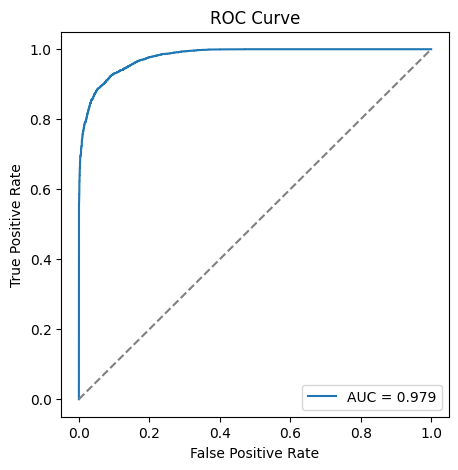

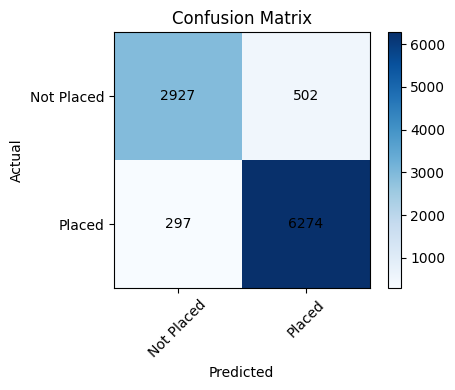


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3429
           1       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000



In [9]:
results_placement = evaluate_classifier(
    placement_model,
    X1_test,
    y1_test,
    class_names=['Not Placed', 'Placed'],
    average='binary'
)

In [10]:
def get_feature_names(
    fitted_preprocessor,
    numeric_columns,
    categorical_columns
):

    ohe = (
        fitted_preprocessor
        .named_transformers_['cat']
        .named_steps['onehot']
    )

    cat_names = ohe.get_feature_names_out(
        categorical_columns
    )

    return list(numeric_columns) + list(cat_names)

print("Feature-name function created.")

Feature-name function created.


Top 15 influential features:


,feature,coefficient
8,CGPA,-2.216254
40,HistoryOfBacklogs_Yes,-2.203858
16,SoftSkillsRating,1.114294
10,Internships,1.034017
4,SGPA_Sem5,0.899571
11,Projects,0.815726
6,SGPA_Sem7,0.808995
7,SGPA_Sem8,0.710821
5,SGPA_Sem6,0.695656
0,SGPA_Sem1,0.620535


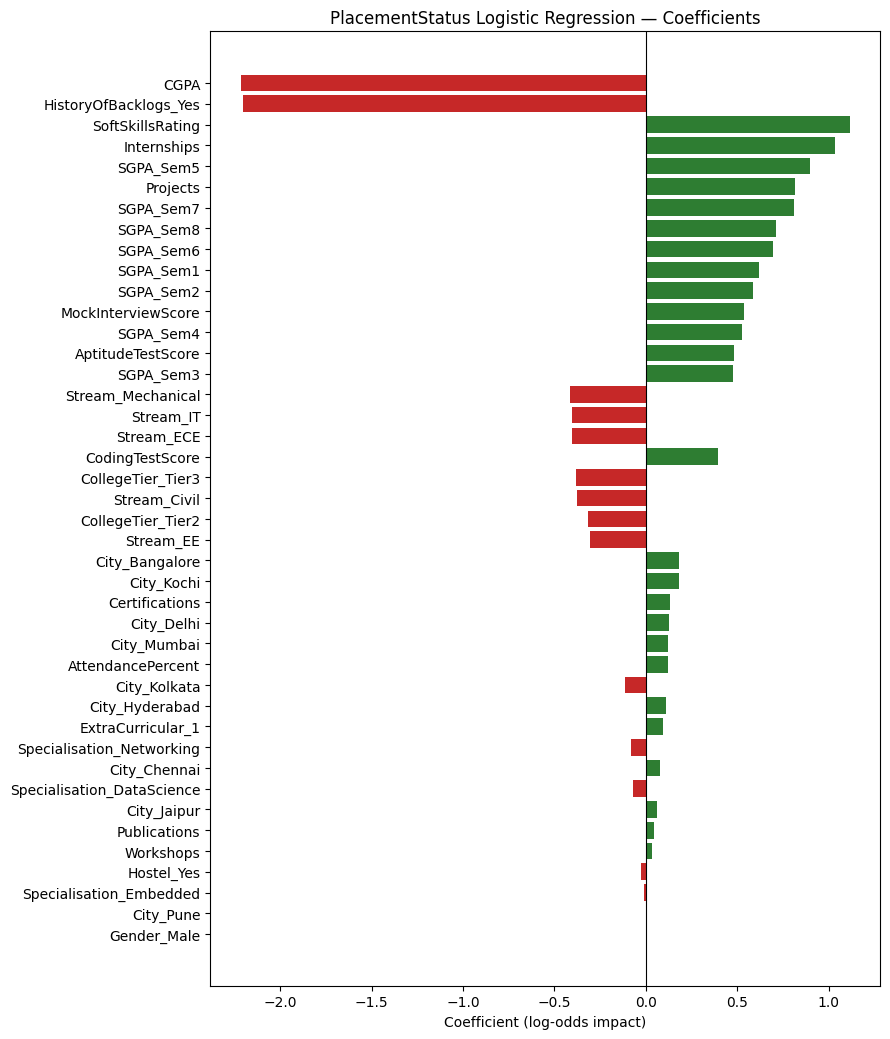

In [11]:
feature_names_1 = get_feature_names(
    placement_model.named_steps['preprocessor'],
    numeric_cols,
    categorical_cols
)

coefs_1 = (
    placement_model
    .named_steps['classifier']
    .coef_[0]
)

coef_df_1 = pd.DataFrame({
    'feature': feature_names_1,
    'coefficient': coefs_1
})

coef_df_1 = coef_df_1.reindex(
    coef_df_1['coefficient']
    .abs()
    .sort_values(ascending=False)
    .index
)

print("Top 15 influential features:")

display(coef_df_1.head(15))

plt.figure(
    figsize=(9, max(6, len(coef_df_1) * 0.25))
)

colors = [
    '#2E7D32' if c > 0 else '#C62828'
    for c in coef_df_1['coefficient']
]

plt.barh(
    coef_df_1['feature'],
    coef_df_1['coefficient'],
    color=colors
)

plt.gca().invert_yaxis()

plt.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.xlabel('Coefficient (log-odds impact)')

plt.title(
    'PlacementStatus Logistic Regression — Coefficients'
)

plt.tight_layout()
plt.show()

In [12]:
numeric_cols_tier = [
    col
    for col in numeric_cols
    if col != 'CGPA'
]

X2 = df[
    numeric_cols_tier + categorical_cols
]

y2 = df['CGPA_Tier']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("CGPA Tier training and testing data prepared.")

CGPA Tier training and testing data prepared.


In [13]:
preprocessor_tier = ColumnTransformer(transformers=[
    (
        'num',
        numeric_transformer,
        numeric_cols_tier
    ),

    (
        'cat',
        categorical_transformer,
        categorical_cols
    )
])

tier_model = Pipeline(steps=[
    (
        'preprocessor',
        preprocessor_tier
    ),

    (
        'classifier',
        LogisticRegression(
            max_iter=2000,
            solver='lbfgs',
            random_state=42
        )
    )
])

tier_model.fit(
    X2_train,
    y2_train
)

print("CGPA Tier model trained successfully.")

CGPA Tier model trained successfully.


Accuracy : 0.9689
Precision: 0.9689
Recall   : 0.9689
F1-score : 0.9689


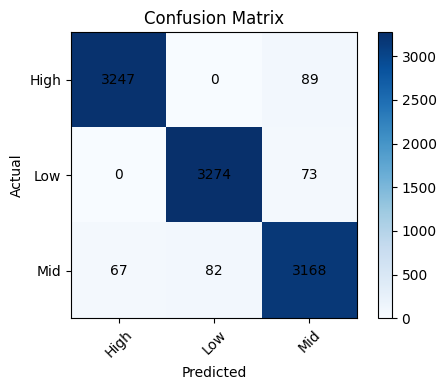


Classification Report:

              precision    recall  f1-score   support

        High       0.98      0.97      0.98      3336
         Low       0.98      0.98      0.98      3347
         Mid       0.95      0.96      0.95      3317

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [14]:
class_order = list(
    tier_model
    .named_steps['classifier']
    .classes_
)

results_tier = evaluate_classifier(
    tier_model,
    X2_test,
    y2_test,
    class_names=class_order,
    average='macro'
)

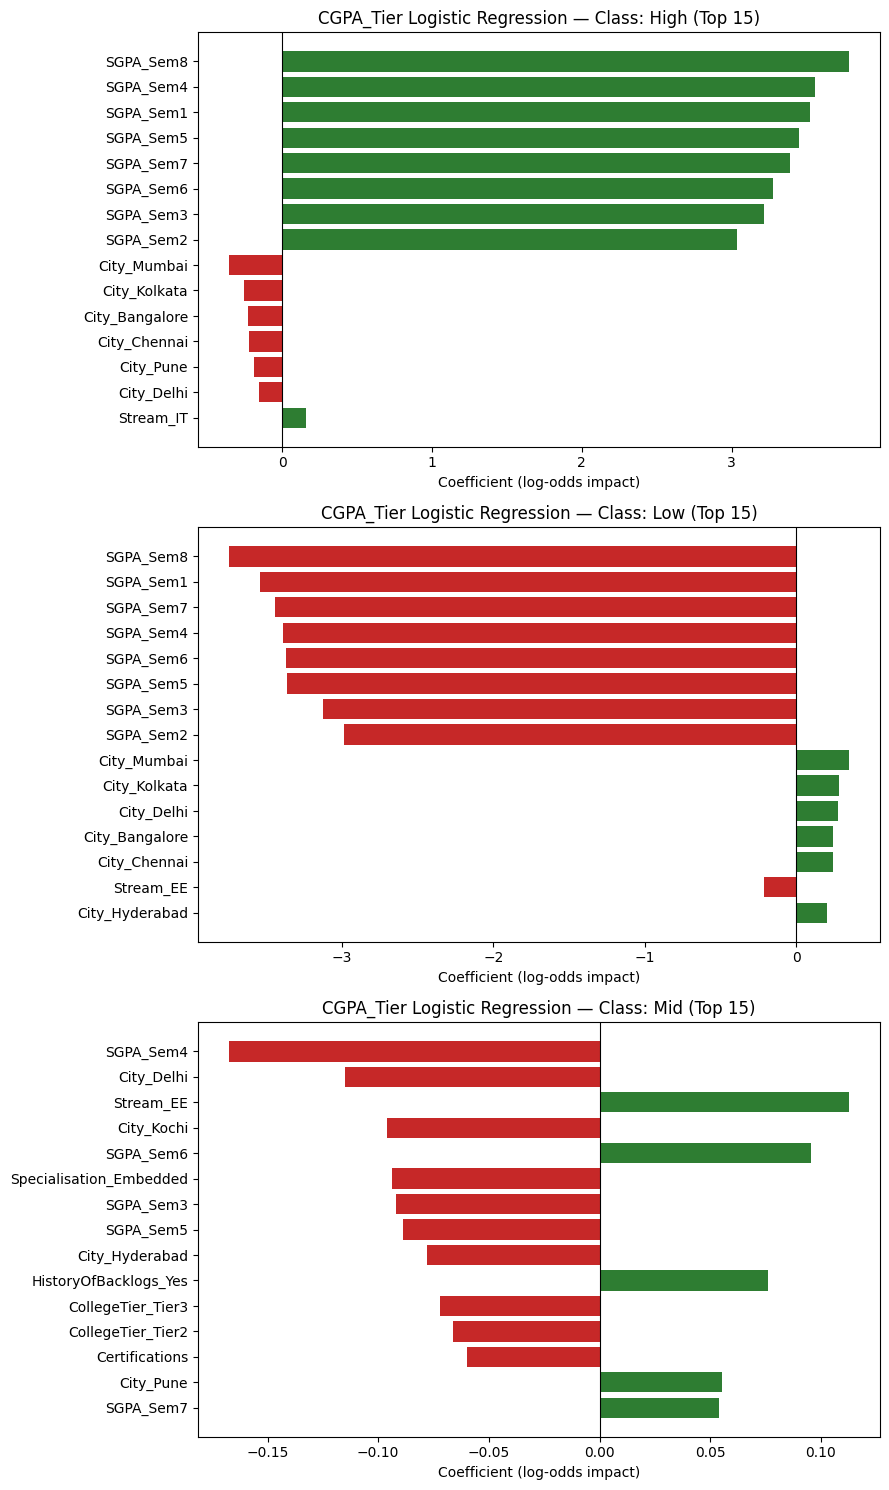

In [15]:
feature_names_2 = get_feature_names(
    tier_model.named_steps['preprocessor'],
    numeric_cols_tier,
    categorical_cols
)

classes_2 = (
    tier_model
    .named_steps['classifier']
    .classes_
)

coefs_2 = (
    tier_model
    .named_steps['classifier']
    .coef_
)

fig, axes = plt.subplots(
    len(classes_2),
    1,
    figsize=(9, 5 * len(classes_2))
)

if len(classes_2) == 1:
    axes = [axes]

for ax, cls, coef_row in zip(
    axes,
    classes_2,
    coefs_2
):

    cdf = pd.DataFrame({
        'feature': feature_names_2,
        'coefficient': coef_row
    })

    cdf = cdf.reindex(
        cdf['coefficient']
        .abs()
        .sort_values(ascending=False)
        .index
    ).head(15)

    colors = [
        '#2E7D32' if c > 0 else '#C62828'
        for c in cdf['coefficient']
    ]

    ax.barh(
        cdf['feature'],
        cdf['coefficient'],
        color=colors
    )

    ax.invert_yaxis()

    ax.axvline(
        0,
        color='black',
        linewidth=0.8
    )

    ax.set_title(
        f'CGPA_Tier Logistic Regression — '
        f'Class: {cls} (Top 15)'
    )

    ax.set_xlabel(
        'Coefficient (log-odds impact)'
    )

plt.tight_layout()
plt.show()

In [16]:
print("=== MODEL COMPARISON ===")

print("\nPlacementStatus Model:")
print(results_placement)

print("\nCGPA Tier Model:")
print(results_tier)

=== MODEL COMPARISON ===

PlacementStatus Model:
{'accuracy': 0.9201, 'precision': 0.9259149940968123, 'recall': 0.9548014000913103, 'f1': 0.9401363602307634}

CGPA Tier Model:
{'accuracy': 0.9689, 'precision': 0.9689000804738352, 'recall': 0.9688635525860202, 'f1': 0.9688764514569419}
